In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from kan import *

# 摆运动方程推断
这是一个 KAN 符号回归的小型示例。
我们使用手机应用 [phyphox](https://phyphox.org/) 采集了 50 cm 细绳摆动过程中的陀螺仪和加速度计数据。加速度计噪声更明显，因此对应损失通常更高。
回归结果给出的角速度约为 4 rad/s，对应完整摆动周期约 0.785 s。

## 数据可视化

C:\Users\chenpeng\AppData\Local\Temp\ipykernel_18048\262805856.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_g = df_g[df_g['Time (s)'] < 175][df_g['Time (s)'] > 170]


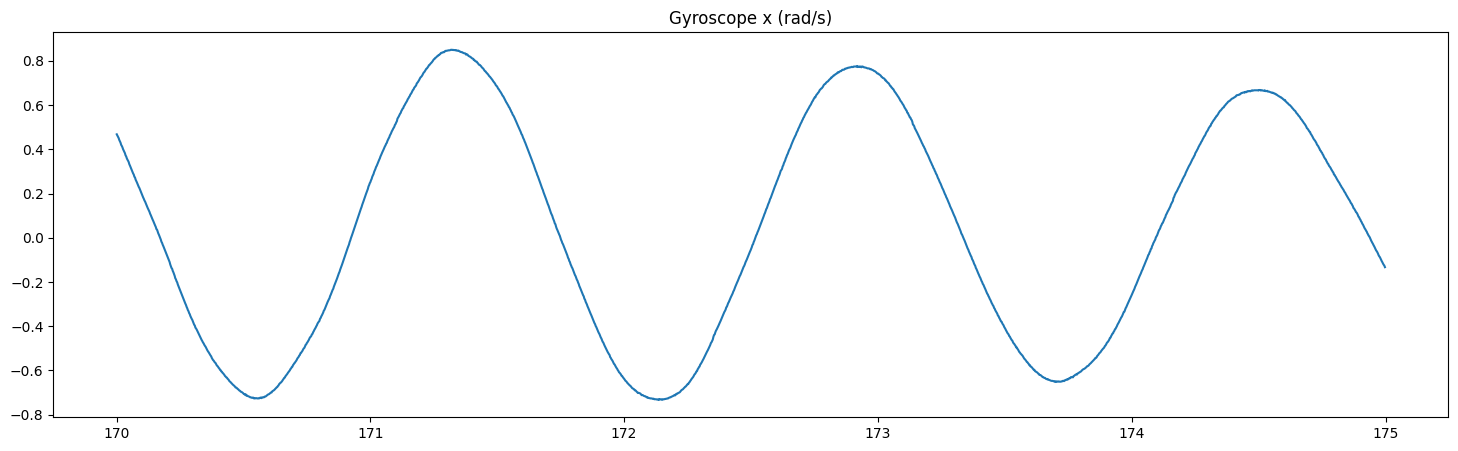

In [2]:
df_g = pd.read_csv('raw/Gyroscope.csv')
df_g = df_g[df_g['Time (s)'] < 175][df_g['Time (s)'] > 170]

fig, ax = plt.subplots()
ax.plot(df_g['Time (s)'], df_g['Gyroscope x (rad/s)'])
fig.set_size_inches(18, 5)
plt.title('Gyroscope x (rad/s)')
plt.show()

C:\Users\chenpeng\AppData\Local\Temp\ipykernel_18048\2088566481.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_a = df_a[df_a['Time (s)'] < 175][df_a['Time (s)'] > 170]


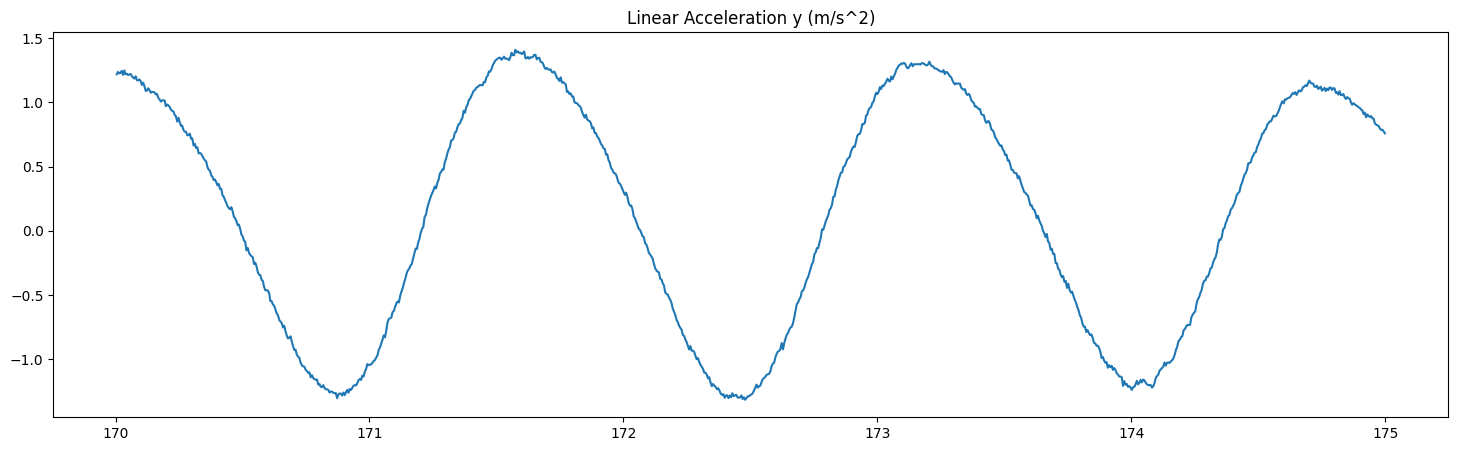

In [3]:
df_a = pd.read_csv('raw/Linear Acceleration.csv')
df_a = df_a[df_a['Time (s)'] < 175][df_a['Time (s)'] > 170]

fig, ax = plt.subplots()
ax.plot(df_a['Time (s)'], df_a['Linear Acceleration y (m/s^2)'])
fig.set_size_inches(18, 5)
plt.title('Linear Acceleration y (m/s^2)')
plt.show()

## 基于 KAN 的加速度符号回归

In [4]:
model = KAN(width=[1, 1], grid=40, k=3, seed=0)
train_set = df_a.sample(frac=0.7, random_state=99)
test_set = df_a.drop(train_set.index)
dataset = {'train_input': torch.tensor(train_set['Time (s)'].values, dtype=torch.float32).view(-1, 1),
           'train_label': torch.tensor(train_set['Linear Acceleration y (m/s^2)'].values, dtype=torch.float32).view(-1, 1),
           'test_input': torch.tensor(test_set['Time (s)'].values, dtype=torch.float32).view(-1, 1),
           'test_label': torch.tensor(test_set['Linear Acceleration y (m/s^2)'].values, dtype=torch.float32).view(-1, 1)}


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.93e-02 | test_loss: 2.12e-02 | reg: 1.12e+00 | : 100%|█| 40/40 [00:01<00:00, 23.24it


saving model version 0.1


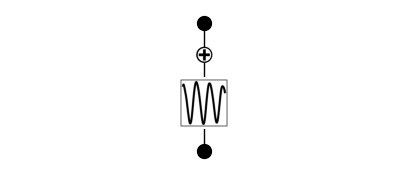

In [5]:
model.fit(dataset, opt="LBFGS", steps=40, lamb=0.1, lamb_entropy=1., lamb_l1=0.1)
model(dataset['train_input'])
model.plot()

fixing (0,0,0) with sin, r2=0.9843672513961792, c=2
saving model version 0.2


1.238*sin(4.0*t - 6.383) + 0.086

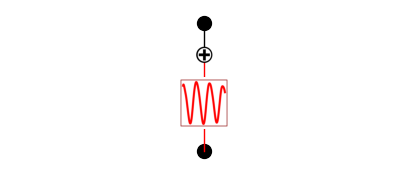

In [6]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model.auto_symbolic(lib=lib)
model.plot()
formula, variables = model.symbolic_formula(var=['t'])
ex_round(formula[0], 3)

## 基于 KAN 的角速度符号回归

In [7]:
model2 = KAN(width=[1, 1], grid=40, k=3, seed=0)
train_set2 = df_g.sample(frac=0.7, random_state=99)
test_set2 = df_g.drop(train_set2.index)
dataset2 = {
    'train_input': torch.tensor(train_set2['Time (s)'].values, dtype=torch.float32).view(-1, 1),
    'train_label': torch.tensor(train_set2['Gyroscope x (rad/s)'].values, dtype=torch.float32).view(-1, 1),
    'test_input': torch.tensor(test_set2['Time (s)'].values, dtype=torch.float32).view(-1, 1),
    'test_label': torch.tensor(test_set2['Gyroscope x (rad/s)'].values, dtype=torch.float32).view(-1, 1)
}


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.50e-03 | test_loss: 3.94e-03 | reg: 0.00e+00 | : 100%|█| 40/40 [00:04<00:00,  8.66it


saving model version 0.1


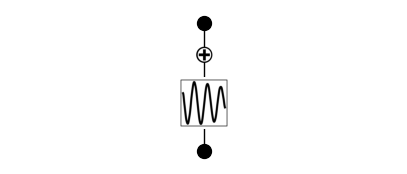

In [8]:
model2.fit(dataset2, opt="LBFGS", steps=40, lamb=0.1, lamb_entropy=0., lamb_l1=0.)
model2(dataset2['train_input'])
model2.plot()

fixing (0,0,0) with sin, r2=0.9932071566581726, c=2
saving model version 0.2


0.04 - 0.735*sin(3.964*t + 4.11)

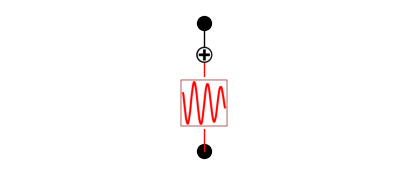

In [9]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model2.auto_symbolic(lib=lib)
model2.plot()
formula, variables = model2.symbolic_formula(var=['t'])
ex_round(formula[0], 3)